# 03 Modeling Gas Usage

This notebook builds and evaluates a **linear regression model** for monthly gas usage.

It follows these steps:
1. Load cleaned gas usage data.
2. Filter invalid rows and keep needed columns.
3. Remove outliers (top 1% high-usage properties + top 1% floor-area rows).
4. Visualize average gas usage vs floor area at property level.
5. Visualize average gas usage vs floor area by property type.
6. Define predictors and target, then create log-transformed features.
7. Build preprocessing and modeling pipeline.
8. Split train/test by **property**.
9. Train the model and generate predictions.
10. Evaluate model performance.
11. Show sample actual vs predicted values.


## 1) Load the cleaned gas usage dataset

Data source: `data/clean/gas_monthly_usage.csv`


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

pd.set_option("display.max_columns", 50)

gas_path = "../data/clean/gas_monthly_usage.csv"
df = pd.read_csv(gas_path)

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
df.head()


Rows: 8,412
Columns: 6


,Property Name,Portfolio Manager ID,Property Type - Self-Selected,Gross Floor Area,month,normalized_monthly_usage
0,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-01-01,23839.31
1,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-02-01,18735.80
2,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-03-01,14082.81
3,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-04-01,11537.50
4,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-05-01,7784.48


## 2) Remove invalid rows and keep required columns

Rules:
- Remove rows where `Gross Floor Area == 1`
- Keep:
  - `Portfolio Manager ID` (property id)
  - `Property Type - Self-Selected`
  - `Gross Floor Area`
  - `month`
  - `normalized_monthly_usage`


In [2]:
required_columns = [
    "Portfolio Manager ID",
    "Property Type - Self-Selected",
    "Gross Floor Area",
    "month",
    "normalized_monthly_usage",
]

MONTH_ORDER = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

df_model = df[required_columns].copy()
df_model = df_model.rename(columns={"Portfolio Manager ID": "property_id"})

rows_before = len(df_model)

df_model["property_id"] = df_model["property_id"].astype("string").str.strip()
df_model["Property Type - Self-Selected"] = (
    df_model["Property Type - Self-Selected"].astype("string").str.strip()
)
df_model["Gross Floor Area"] = pd.to_numeric(df_model["Gross Floor Area"], errors="coerce")
df_model["normalized_monthly_usage"] = pd.to_numeric(df_model["normalized_monthly_usage"], errors="coerce")
df_model["month"] = pd.to_datetime(df_model["month"], errors="coerce")

df_model = df_model[df_model["Gross Floor Area"] != 1].copy()

valid_mask = (
    df_model["property_id"].notna()
    & df_model["property_id"].ne("")
    & df_model["Property Type - Self-Selected"].notna()
    & df_model["Property Type - Self-Selected"].ne("")
    & df_model["Gross Floor Area"].notna()
    & df_model["month"].notna()
    & df_model["normalized_monthly_usage"].notna()
)

df_model = df_model.loc[valid_mask].copy()
df_model["month"] = pd.Categorical(
    df_model["month"].dt.strftime("%b"),
    categories=MONTH_ORDER,
    ordered=True,
)

print(f"Rows before cleaning: {rows_before:,}")
print(f"Rows after cleaning: {len(df_model):,}")
print(f"Rows removed: {rows_before - len(df_model):,}")
print(f"Unique properties: {df_model['property_id'].nunique():,}")
df_model.head()


Rows before cleaning: 8,412
Rows after cleaning: 8,052
Rows removed: 360
Unique properties: 671


,property_id,Property Type - Self-Selected,Gross Floor Area,month,normalized_monthly_usage
0,35000838,Utilities / Infrastructure,325447,Jan,23839.31
1,35000838,Utilities / Infrastructure,325447,Feb,18735.80
2,35000838,Utilities / Infrastructure,325447,Mar,14082.81
3,35000838,Utilities / Infrastructure,325447,Apr,11537.50
4,35000838,Utilities / Infrastructure,325447,May,7784.48


## 3) Remove outliers

Outlier removal strategy (aligned with `03-modeling.ipynb`):
1. Remove the top 1% of properties by average `normalized_monthly_usage`.
2. From the remaining rows, remove the top 1% rows by `Gross Floor Area`.


In [3]:
# 3.1 Remove top 1% properties by average normalized monthly usage
property_avg_usage = (
    df_model.groupby("property_id", as_index=False)["normalized_monthly_usage"]
    .mean()
    .rename(columns={"normalized_monthly_usage": "avg_normalized_monthly_usage"})
)

property_count = len(property_avg_usage)
usage_outlier_property_count = max(1, int(np.ceil(property_count * 0.01))) if property_count > 0 else 0

usage_outlier_property_ids = (
    property_avg_usage
    .nlargest(usage_outlier_property_count, "avg_normalized_monthly_usage")["property_id"]
    if usage_outlier_property_count > 0
    else pd.Series(dtype="string")
)

df_after_usage_outlier_removal = df_model.loc[
    ~df_model["property_id"].isin(usage_outlier_property_ids)
].copy()

# 3.2 Remove top 1% rows by Gross Floor Area from the remaining data
area_outlier_row_count = (
    max(1, int(np.ceil(len(df_after_usage_outlier_removal) * 0.01)))
    if len(df_after_usage_outlier_removal) > 0
    else 0
)

area_outlier_indices = (
    df_after_usage_outlier_removal["Gross Floor Area"].nlargest(area_outlier_row_count).index
    if area_outlier_row_count > 0
    else pd.Index([])
)

df_filtered = df_after_usage_outlier_removal.drop(index=area_outlier_indices).copy()

print(f"Properties before outlier removal: {df_model['property_id'].nunique():,}")
print(f"Top 1% usage outlier properties removed: {usage_outlier_property_count:,}")
print(f"Rows removed by usage-outlier properties: {len(df_model) - len(df_after_usage_outlier_removal):,}")
print(f"Top 1% GFA rows removed: {area_outlier_row_count:,}")
print(f"Rows after outlier removal: {len(df_filtered):,}")
print(f"Unique properties after outlier removal: {df_filtered['property_id'].nunique():,}")


Properties before outlier removal: 671
Top 1% usage outlier properties removed: 7
Rows removed by usage-outlier properties: 84
Top 1% GFA rows removed: 80
Rows after outlier removal: 7,888
Unique properties after outlier removal: 658


## 4) Visual check: average usage vs floor area

Create a property-level scatter plot to inspect whether average monthly gas usage has a roughly linear relationship with gross floor area.


Pearson correlation (area vs avg usage): 0.687


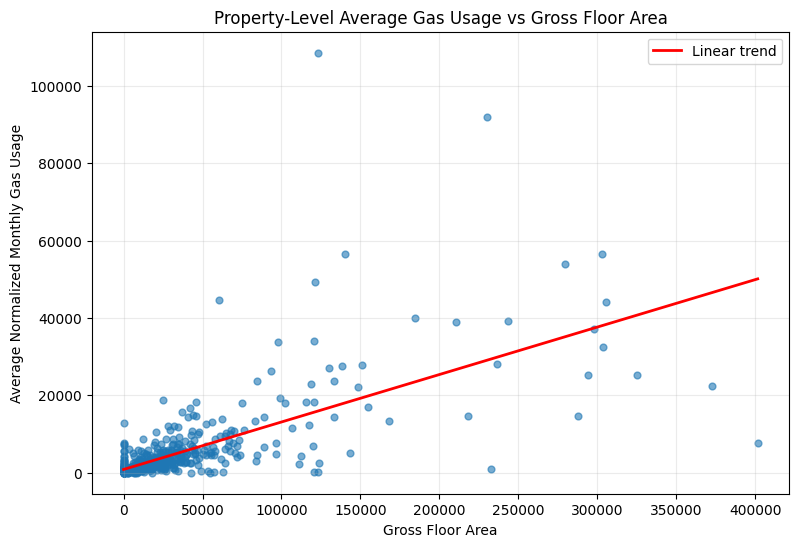

In [4]:
property_scatter_df = (
    df_filtered.groupby("property_id", as_index=False)
    .agg(
        avg_normalized_monthly_usage=("normalized_monthly_usage", "mean"),
        gross_floor_area=("Gross Floor Area", "median"),
    )
)

plt.figure(figsize=(9, 6))
plt.scatter(
    property_scatter_df["gross_floor_area"],
    property_scatter_df["avg_normalized_monthly_usage"],
    alpha=0.6,
    s=24,
)

# Optional linear trend line for quick visual assessment
x = property_scatter_df["gross_floor_area"].to_numpy()
y = property_scatter_df["avg_normalized_monthly_usage"].to_numpy()
coef = np.polyfit(x, y, 1)
x_line = np.array([x.min(), x.max()])
y_line = coef[0] * x_line + coef[1]
plt.plot(x_line, y_line, color="red", linewidth=2, label="Linear trend")

plt.xlabel("Gross Floor Area")
plt.ylabel("Average Normalized Monthly Gas Usage")
plt.title("Property-Level Average Gas Usage vs Gross Floor Area")
plt.grid(alpha=0.25)
plt.legend()

corr = property_scatter_df["gross_floor_area"].corr(
    property_scatter_df["avg_normalized_monthly_usage"]
)
print(f"Pearson correlation (area vs avg usage): {corr:.3f}")

plt.show()


## 5) Visual check by property type (7 plots)

Create separate scatter plots of **average monthly gas usage vs gross floor area** for each property type.
Each subplot represents one property category.


Property types found: 7


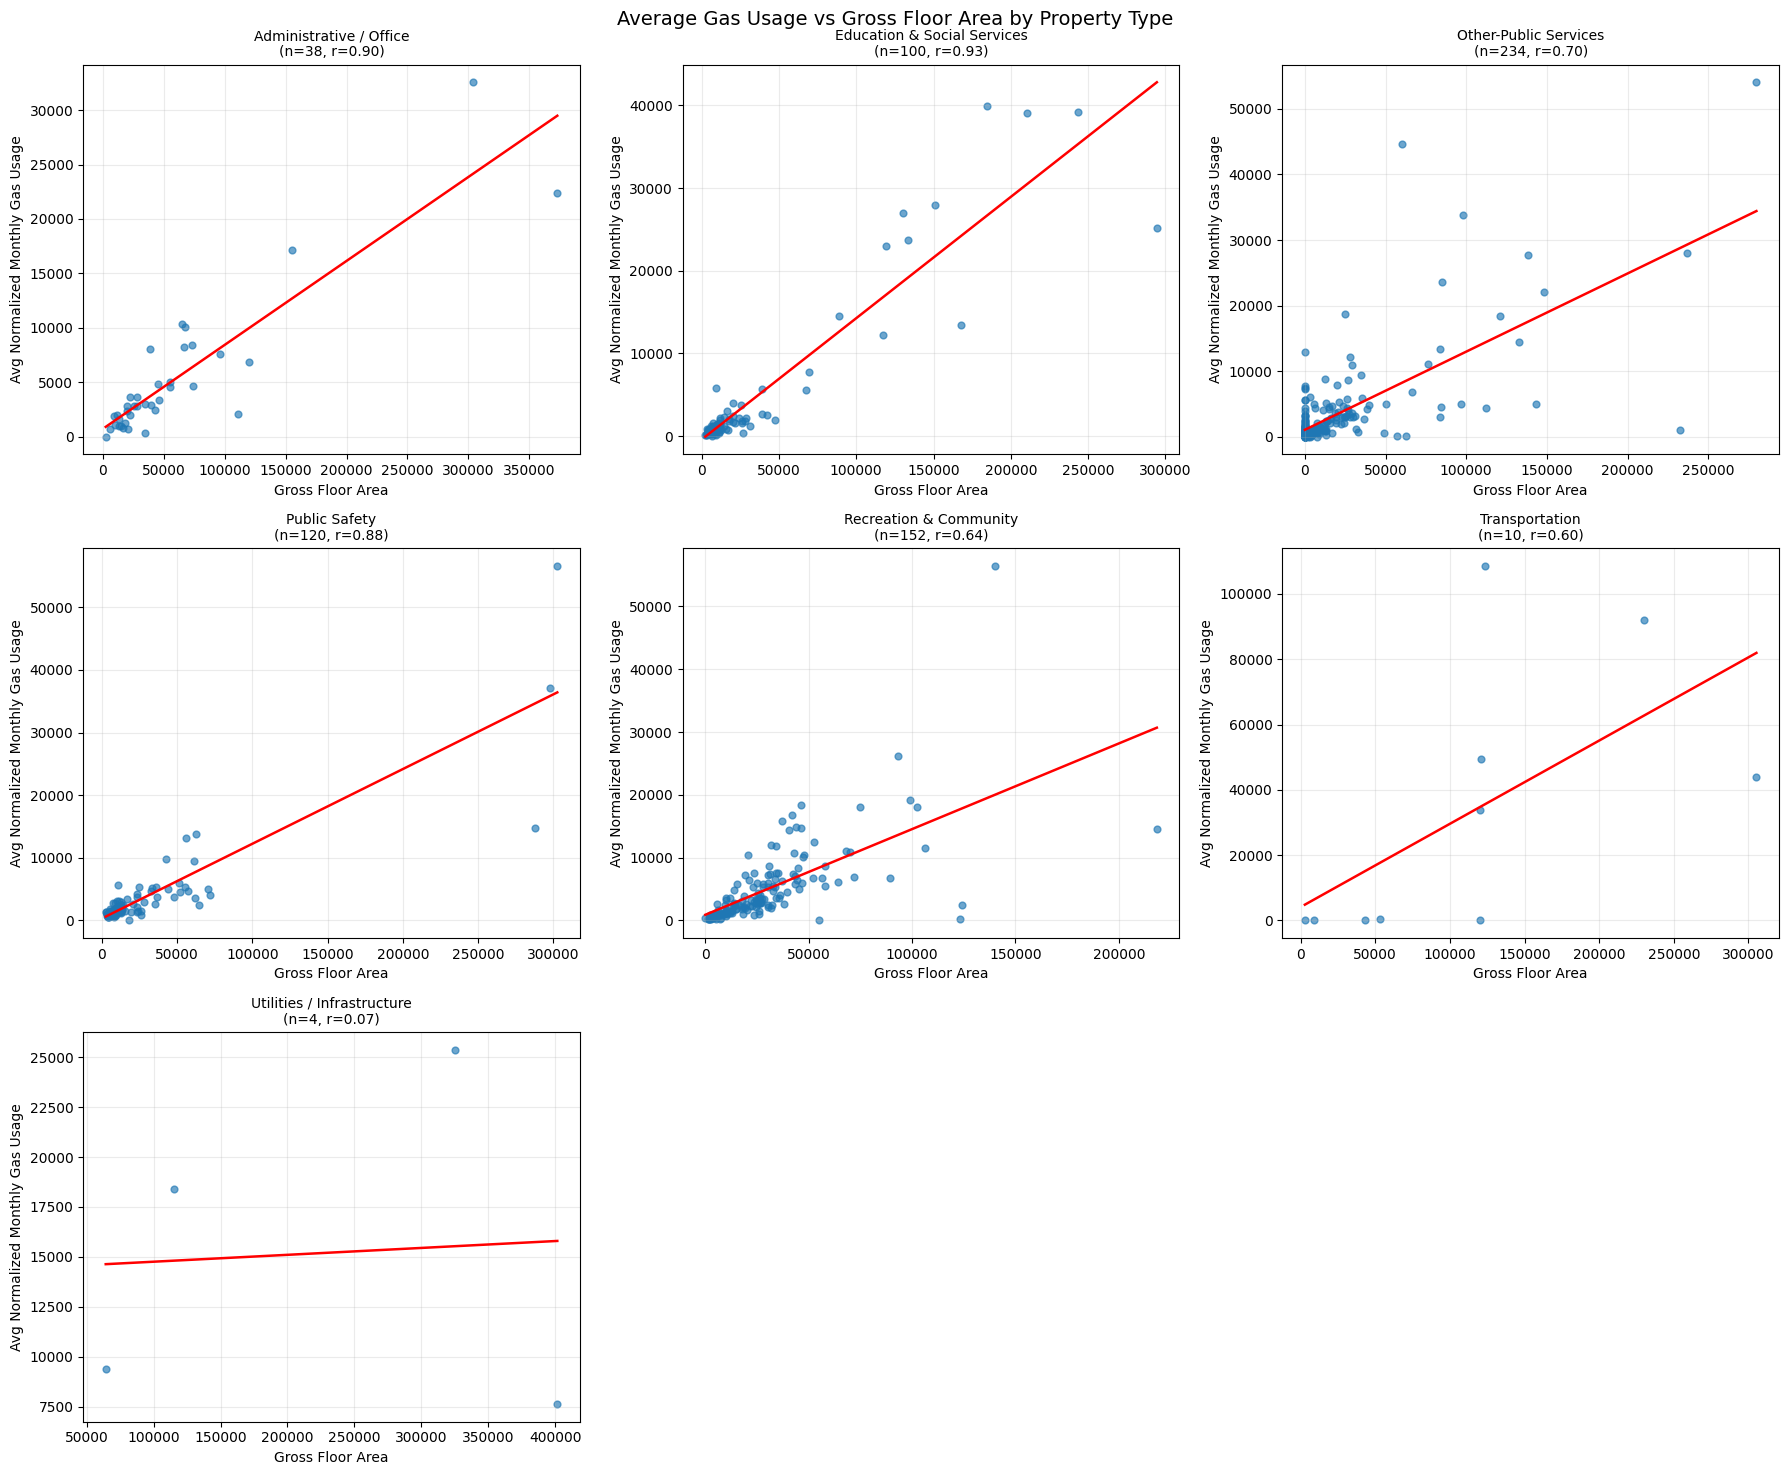

In [5]:
property_type_scatter_df = (
    df_filtered.groupby(["property_id", "Property Type - Self-Selected"], as_index=False)
    .agg(
        avg_normalized_monthly_usage=("normalized_monthly_usage", "mean"),
        gross_floor_area=("Gross Floor Area", "median"),
    )
)

property_types = sorted(property_type_scatter_df["Property Type - Self-Selected"].dropna().unique())
print(f"Property types found: {len(property_types)}")

n_cols = 3
n_rows = int(np.ceil(len(property_types) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows), sharex=False, sharey=False)
axes = np.array(axes).reshape(-1)

for i, ptype in enumerate(property_types):
    ax = axes[i]
    subset = property_type_scatter_df[
        property_type_scatter_df["Property Type - Self-Selected"] == ptype
    ]

    ax.scatter(
        subset["gross_floor_area"],
        subset["avg_normalized_monthly_usage"],
        alpha=0.65,
        s=24,
    )

    # Draw trend line only when enough points exist
    if len(subset) >= 2:
        x = subset["gross_floor_area"].to_numpy()
        y = subset["avg_normalized_monthly_usage"].to_numpy()
        coef = np.polyfit(x, y, 1)
        x_line = np.array([x.min(), x.max()])
        y_line = coef[0] * x_line + coef[1]
        ax.plot(x_line, y_line, color="red", linewidth=1.8)

        corr = subset["gross_floor_area"].corr(subset["avg_normalized_monthly_usage"])
        corr_text = f"r={corr:.2f}" if pd.notna(corr) else "r=NA"
    else:
        corr_text = "r=NA"

    ax.set_title(f"{ptype}\n(n={len(subset)}, {corr_text})", fontsize=10)
    ax.set_xlabel("Gross Floor Area")
    ax.set_ylabel("Avg Normalized Monthly Gas Usage")
    ax.grid(alpha=0.25)

# Hide unused subplot slots
for j in range(len(property_types), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Average Gas Usage vs Gross Floor Area by Property Type", fontsize=14)
plt.tight_layout()
plt.show()


## 6) Define predictors and target + create log transforms

Predictors:
- Categorical: `month`, `Property Type - Self-Selected`
- Numeric: `log_gross_floor_area` (from `Gross Floor Area`)

Target:
- `log_target` (log transform of `normalized_monthly_usage`)


In [6]:
df_filtered = df_filtered.copy()
df_filtered["month"] = df_filtered["month"].astype(str)

df_filtered["log_gross_floor_area"] = np.log1p(df_filtered["Gross Floor Area"])
df_filtered["log_target"] = np.log1p(df_filtered["normalized_monthly_usage"])

categorical_features = ["month", "Property Type - Self-Selected"]
numeric_features = ["log_gross_floor_area"]
feature_cols = categorical_features + numeric_features

target_col = "log_target"
id_col = "property_id"

X = df_filtered[feature_cols].copy()
y = df_filtered[target_col].copy()

print("Feature columns:", feature_cols)
print("Target column:", target_col)


Feature columns: ['month', 'Property Type - Self-Selected', 'log_gross_floor_area']
Target column: log_target


## 7) Build preprocessing + linear regression pipeline

- One-hot encode categorical features
- Pass numeric feature through unchanged
- Fit `LinearRegression`


In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features),
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression()),
    ]
)

model


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

## 8) Train/test split by property (group-aware split)

Each property has monthly records. To avoid leakage, we split on `property_id` so one property appears in only one split.


In [8]:
unique_property_ids = df_filtered[id_col].drop_duplicates()

train_ids, test_ids = train_test_split(
    unique_property_ids,
    test_size=0.20,
    random_state=42,
)

train_mask = df_filtered[id_col].isin(train_ids)
test_mask = df_filtered[id_col].isin(test_ids)

X_train = X.loc[train_mask]
y_train = y.loc[train_mask]
X_test = X.loc[test_mask]
y_test = y.loc[test_mask]

print(f"Train properties: {len(train_ids):,}")
print(f"Test properties: {len(test_ids):,}")
print(f"Train rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")


Train properties: 526
Test properties: 132
Train rows: 6,304
Test rows: 1,584


## 9) Train model and generate predictions


In [9]:
model.fit(X_train, y_train)

y_train_pred_log = model.predict(X_train)
y_test_pred_log = model.predict(X_test)

# Convert predictions and targets back to original usage scale
y_train_actual = np.expm1(y_train)
y_test_actual = np.expm1(y_test)
y_train_pred = np.expm1(y_train_pred_log)
y_test_pred = np.expm1(y_test_pred_log)


## 10) Evaluate performance (R2, MAE, RMSE)

- `R2_log_space` is calculated using log-transformed target/predictions.
- `R2_normal_space`, `MAE`, and `RMSE` are calculated on the original usage scale.


In [10]:
def evaluate_regression(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
    }

# Normal-scale metrics
train_metrics_normal = evaluate_regression(y_train_actual, y_train_pred)
test_metrics_normal = evaluate_regression(y_test_actual, y_test_pred)
metrics_normal_df = pd.DataFrame([train_metrics_normal, test_metrics_normal], index=["Train", "Test"])

# Log-space R2
r2_log_train = r2_score(y_train, y_train_pred_log)
r2_log_test = r2_score(y_test, y_test_pred_log)

r2_comparison_df = pd.DataFrame(
    {
        "R2_log_space": [r2_log_train, r2_log_test],
        "R2_normal_space": [train_metrics_normal["R2"], test_metrics_normal["R2"]],
    },
    index=["Train", "Test"],
)

print("R2 comparison (log vs normal scale):")
display(r2_comparison_df)

print("Full normal-scale metrics:")
metrics_normal_df


R2 comparison (log vs normal scale):


,R2_log_space,R2_normal_space
Train,0.442286,0.130236
Test,0.486585,0.211579


Full normal-scale metrics:


,R2,MAE,RMSE
Train,0.130236,3062.517648,11617.795884
Test,0.211579,2966.044963,9084.233435


## 11) Sample actual vs predicted values

Values shown below are on the **normal/original usage scale** (after reversing log with `np.expm1`).


In [11]:
test_results = pd.DataFrame({
    "property_id": df_filtered.loc[test_mask, id_col].values,
    "month": df_filtered.loc[test_mask, "month"].values,
    "actual_usage": y_test_actual.values,
    "predicted_usage": y_test_pred,
})

test_results["abs_error"] = (test_results["actual_usage"] - test_results["predicted_usage"]).abs()

test_results.head(12)


,property_id,month,actual_usage,predicted_usage,abs_error
0,35000840,Jan,15478.21,29203.647458,13725.437458
1,35000840,Feb,21112.64,24330.624851,3217.984851
2,35000840,Mar,29256.74,21997.970125,7258.769875
3,35000840,Apr,20662.46,14230.959719,6431.500281
4,35000840,May,16913.57,4343.577992,12569.992008
5,35000840,Jun,11708.58,2138.589063,9569.990937
6,35000840,Jul,9883.19,1518.921944,8364.268056
7,35000840,Aug,8372.94,1531.425789,6841.514211
8,35000840,Sep,8876.13,1980.060177,6896.069823
9,35000840,Oct,15724.26,9063.570728,6660.689272
